In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import numpy as np

In [7]:
DATA_DIR = "../data"
# Load the 3 flavor chemistry datasets (they are tab-separated)
ingr_info = pd.read_csv('{}/ingr_info.tsv'.format(DATA_DIR), sep='\t')
comp_info = pd.read_csv('{}/comp_info.tsv'.format(DATA_DIR), sep='\t')
ingr_comp = pd.read_csv('{}/ingr_comp.tsv'.format(DATA_DIR), sep='\t')

# Clean the column names (removing the '#' and extra spaces)
ingr_info.columns = [col.strip('# ').strip() for col in ingr_info.columns]
comp_info.columns = [col.strip('# ').strip() for col in comp_info.columns]
ingr_comp.columns = [col.strip('# ').strip() for col in ingr_comp.columns]

# Merge them together into one massive flavor mapping DataFrame
merged_df = pd.merge(ingr_comp, ingr_info, left_on='ingredient id', right_on='id', how='left')
merged_df = pd.merge(merged_df, comp_info, left_on='compound id', right_on='id', how='left', suffixes=('_ingr', '_comp'))

In [ ]:
# 2. Self-join the ingredient-compound mapping to find pairs of ingredients that share compounds
# We use ingredient id_A < ingredient id_B to avoid getting duplicates (A-B and B-A) or self-pairs (A-A)
pairs = pd.merge(ingr_comp, ingr_comp, on='compound id', suffixes=('_A', '_B'))
pairs = pairs[pairs['ingredient id_A'] < pairs['ingredient id_B']]

# 3. Count the number of shared chemical compounds for each pair
shared_counts = pairs.groupby(['ingredient id_A', 'ingredient id_B']).size().reset_index(name='shared_compounds')

# 4. Add names and categories for Ingredient A
shared_counts = pd.merge(shared_counts, ingr_info[['id', 'ingredient name', 'category']], left_on='ingredient id_A', right_on='id')
shared_counts = shared_counts.rename(columns={'ingredient name': 'Ingredient A', 'category': 'Category A'}).drop('id', axis=1)

# 5. Add names and categories for Ingredient B
shared_counts = pd.merge(shared_counts, ingr_info[['id', 'ingredient name', 'category']], left_on='ingredient id_B', right_on='id')
shared_counts = shared_counts.rename(columns={'ingredient name': 'Ingredient B', 'category': 'Category B'}).drop('id', axis=1)

# 6. Filter for "Unconventional Pairings" 
# (Where Category A and Category B are completely different, e.g., Meat vs Fruit)
unconventional_pairs = shared_counts[shared_counts['Category A'] != shared_counts['Category B']]

# 7. Sort by the highest number of shared compounds
unconventional_pairs = unconventional_pairs.sort_values(by='shared_compounds', ascending=False)

# Display the top 20 mind-blowing pairings
print("--- Top 20 Scientifically Proven Unconventional Pairings ---")
print(unconventional_pairs[['Ingredient A', 'Category A', 'Ingredient B', 'Category B', 'shared_compounds']].head(20).to_string(index=False))

# 8. Export the full network for your D3.js Force-Directed Graph!
# We'll save the top 500 pairings to keep the web visualization running smoothly
# unconventional_pairs.head(500).to_csv('d3_flavor_network_pairings.csv', index=False)

--- Top 20 Scientifically Proven Unconventional Pairings ---
 Ingredient A         Category A   Ingredient B         Category B  shared_compounds
peanut_butter   plant derivative roasted_peanut     nut/seed/pulse               144
 cooked_apple              fruit     white_wine alcoholic beverage               106
 roasted_beef               meat     bantu_beer alcoholic beverage               106
 roasted_beef               meat           beer alcoholic beverage               106
 grilled_beef               meat         coffee   plant derivative               106
       coffee   plant derivative     fried_beef               meat               106
 roasted_beef               meat         coffee   plant derivative               105
 roasted_beef               meat roasted_peanut     nut/seed/pulse               105
        apple              fruit     white_wine alcoholic beverage               105
peanut_butter   plant derivative   roasted_beef               meat               105
pean

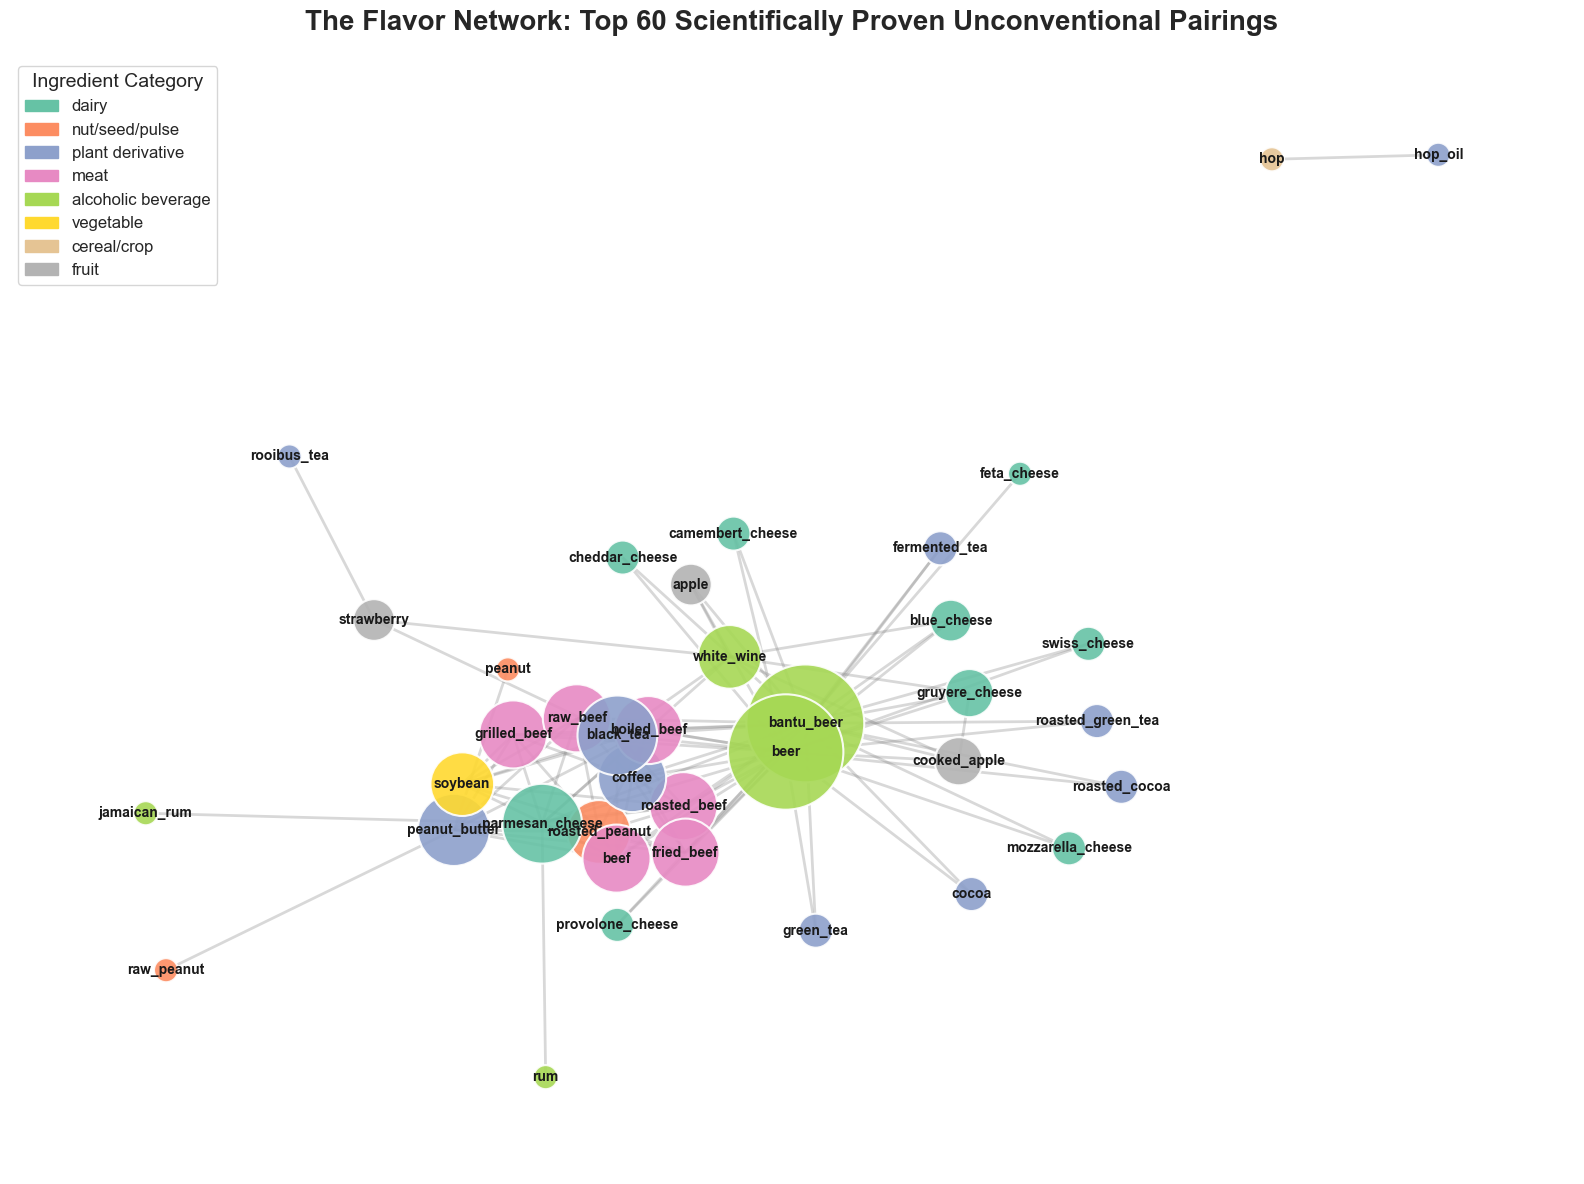

In [ ]:
top_edges = unconventional_pairs.head(60)

# 1. Initialize the Network Graph
G = nx.Graph()

# 2. Add the ingredients as "Nodes" and the shared compounds as "Edges"
for _, row in top_edges.iterrows():
    G.add_node(row['Ingredient A'], category=row['Category A'])
    G.add_node(row['Ingredient B'], category=row['Category B'])
    
    # We add a line connecting them, weighted by how many chemicals they share
    G.add_edge(row['Ingredient A'], row['Ingredient B'], weight=row['shared_compounds'])

# 3. Set up the plotting canvas
plt.figure(figsize=(16, 12))
plt.title("The Flavor Network: Top 60 Scientifically Proven Unconventional Pairings", fontsize=20, fontweight='bold', pad=20)

# 4. Color Code the Ingredients by their Biological Category (Meat, Fruit, etc.)
unique_categories = set(nx.get_node_attributes(G, 'category').values())
color_palette = sns.color_palette("Set2", len(unique_categories))
category_colors = dict(zip(unique_categories, color_palette))
node_colors = [category_colors[node[1]['category']] for node in G.nodes(data=True)]

# 5. Make the bubbles bigger if they have a lot of connections
node_sizes = [G.degree(node) * 300 for node in G.nodes()]

# 6. Apply a "Spring Layout" (This simulates gravity, pulling connected foods together!)
pos = nx.spring_layout(G, k=0.6, iterations=10, seed=40)

# Draw the lines (edges)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=2, edge_color='gray')

# Draw the bubbles (nodes)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, edgecolors='white', linewidths=1.5)

# Add the ingredient names
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_family='sans-serif')

# 7. Create a custom Legend so we know what the colors mean
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_colors.items()]
plt.legend(handles=legend_handles, title="Ingredient Category", loc='upper left', frameon=True, fontsize=12, title_fontsize=14)

# Hide the grid/axes and show the masterpiece!
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Merge into a single dataframe focused on the compounds
merged_df = pd.merge(ingr_comp, ingr_info, left_on='ingredient id', right_on='id', how='left')
merged_df = pd.merge(merged_df, comp_info, left_on='compound id', right_on='id', how='left')

# We want to focus on the TOP 20 most common compounds globally
top_20_compounds = merged_df['Compound name'].value_counts().head(20).index.tolist()
top_10_categories = merged_df['category'].value_counts().head(10).index.tolist()

# --- VIZ 1: Compound Distribution by Category (Heatmap) ---
# Filter data for top compounds and categories
cat_comp_data = merged_df[(merged_df['Compound name'].isin(top_20_compounds)) & (merged_df['category'].isin(top_10_categories))]

# Create a pivot table counting how many times a compound appears in a category
pivot_heat = cat_comp_data.pivot_table(index='Compound name', columns='category', values='ingredient id', aggfunc='count', fill_value=0)

# Sort the index by total frequency for a nicer visual gradient
pivot_heat['Total'] = pivot_heat.sum(axis=1)
pivot_heat = pivot_heat.sort_values(by='Total', ascending=True).drop('Total', axis=1)

# --- VIZ 2: Compound Co-occurrence (Which compounds travel together?) ---
co_data = merged_df[merged_df['Compound name'].isin(top_20_compounds)][['ingredient id', 'Compound name']].copy()
co_data['value'] = 1

# Create a binary matrix: 1 if ingredient has the compound, 0 if not
pivot_co = co_data.pivot_table(index='ingredient id', columns='Compound name', values='value', fill_value=0)

# Matrix multiplication to calculate how often compounds co-occur!
co_matrix = pivot_co.T.dot(pivot_co)

# Set diagonal to zero to avoid blowing up the color scale (a compound always occurs 100% with itself)
np.fill_diagonal(co_matrix.values, 0)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# 1. Distribution Heatmap
sns.heatmap(pivot_heat, cmap='YlGnBu', ax=axes[0], annot=True, fmt="d", linewidths=.5)
axes[0].set_title('Where Do the Top 20 Flavor Compounds Live?', fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel('Flavor Compound', fontsize=12)
axes[0].set_xlabel('Ingredient Category', fontsize=12)

# 2. Co-occurrence Matrix
sns.heatmap(co_matrix, cmap='rocket_r', ax=axes[1], annot=False, linewidths=.5)
axes[1].set_title('Compound Co-occurrence\n(Which molecules travel together?)', fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel('')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# Export matrices for D3 interactive Heatmaps and Chord Diagrams!
#pivot_heat.to_csv('d3_compound_category_heatmap.csv')
#co_matrix.to_csv('d3_compound_cooccurrence.csv')

NameError: name 'np' is not defined